In [86]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [97]:
demand = pd.read_csv(
    # Path.cwd().parent / 'resources' / 'industrial_energy_demand_base_s_50_2025.csv', index_col=0
    Path.cwd().parent / 'resources' / 'industrial_energy_demand_per_country_today.csv', index_col=0, header=[0, 1]
)

In [123]:
demand

AL                                 \
            Alumina production Aluminium - primary production   
TWh/a                                                           
ammonia                    0.0                            0.0   
biomass                    0.0                            0.0   
electricity                0.0                            0.0   
gas                        0.0                            0.0   
heat                       0.0                            0.0   
hydrogen                   0.0                            0.0   
liquid                     0.0                            0.0   
other                      0.0                           -0.0   
solid                      0.0                            0.0   
waste                      0.0                            0.0   

                                                                    \
            Aluminium - secondary production Ammonia        Cement   
TWh/a                                                                
ammonia                                  0.0     0.0  0.000000e+00   
biomass                                  0.0     0.0  1.906630e-03   
electricity                              0.0     0.0  2.817006e-03   
gas                                      0.0     0.0  9.535426e-03   
heat                                     0.0     0.0  2.144612e-04   
hydrogen                                 0.0     0.0  0.000000e+00   
liquid                                   0.0     0.0  6.124493e-03   
other                                   -0.0     0.0 -1.255286e-18   
solid                                    0.0     0.0  3.262325e-03   
waste                                    0.0     0.0  4.798959e-03   

                                                          \
            Ceramics & other NMM  Chlorine  Electric arc   
TWh/a                                                      
ammonia             0.000000e+00  0.000000  0.000000e+00   
biomass             1.860580e-03  0.000000  1.745756e-04   
electricity         5.759261e-03  0.011160  6.071055e-02   
gas                 1.285101e-02  0.000000  3.241683e-02   
heat                4.057514e-04  0.000000  2.162600e-03   
hydrogen            0.000000e+00 -0.002905  0.000000e+00   
liquid              5.542503e-03  0.000000  2.096589e-03   
other              -6.306161e-19  0.000000 -2.724209e-18   
solid               3.401920e-03  0.000000  1.406566e-03   
waste               3.604022e-03  0.000000  5.335114e-06   

                                                          ...              XK  \
            Food, beverages and tobacco Glass production  ... Other chemicals   
TWh/a                                                     ...                   
ammonia                    0.000000e+00     0.000000e+00  ...    0.000000e+00   
biomass                    2.959699e-02     3.763335e-05  ...    3.283821e-05   
electricity                2.006112e-01     3.650089e-03  ...    9.666255e-04   
gas                        2.649908e-01     6.422005e-03  ...    1.323223e-03   
heat                       2.977809e-02     0.000000e+00  ...    5.014533e-04   
hydrogen                   0.000000e+00     0.000000e+00  ...    0.000000e+00   
liquid                     3.005989e-02     4.658897e-04  ...    4.316407e-04   
other                      2.431179e-17    -9.447981e-20  ...   -2.187968e-19   
solid                      2.391242e-02     1.656717e-03  ...    2.662675e-04   
waste                      1.536753e-04     0.000000e+00  ...    2.949609e-05   

                                                               \
            Other industrial sectors Other non-ferrous metals   
TWh/a                                                           
ammonia                 0.000000e+00                      0.0   
biomass                 1.848777e-02                      0.0   
electricity             1.937139e-01                      0.0   
gas                     9.114439e-02          

In [106]:
production = pd.read_csv(
    # Path.cwd().parent / 'resources' / 'industrial_production_base_s_50_2025.csv', index_col=0
    Path.cwd().parent / 'resources' / 'industrial_production_per_country.csv', index_col=0
).stack() / 1e3
production.index.names = [None, None]

In [ ]:
production

AL  Electric arc                    0.07267
    Integrated steelworks           0.09864
    Other chemicals                 0.00742
    Pharmaceutical products etc.    0.00284
    Cement                          0.03315
                                     ...   
XK  Other industrial sectors        1.41518
    Ammonia                         0.00000
    HVC                             0.00152
    Chlorine                        0.00028
    Methanol                        0.00004
Length: 816, dtype: float64

In [152]:
ratios_tomorrow = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industry_sector_ratios.csv', index_col=0
)

In [117]:
ratios_today = demand.div(production, axis=1).replace([np.inf, -np.inf], 0).dropna(how='all', axis=1)

In [154]:
ratios_tomorrow.index

Index(['elec', 'coal', 'coke', 'biomass', 'methane', 'hydrogen', 'heat',
       'naphtha', 'ammonia', 'methanol', 'process emission',
       'process emission from feedstock'],
      dtype='object', name='MWh/tMaterial')

In [165]:
mapper = {
    'gas': 'methane',
    'liquid': 'naphtha',
    'solid': 'coke',
    'electricity': 'elec',
    'other': 'biomass',
    'waste': 'biomass',
    }

/tmp/ipykernel_738652/360299082.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  for _, (pair, values) in enumerate((r := ratios_today.stack()).loc[r.std(axis=1).sort_values(ascending=False).index].iterrows()):


('gas', 'HVC')
tomorrow value 3.2946866053362114
('gas', 'Pharmaceutical products etc.')
tomorrow value 0.0
('gas', 'Aluminium - primary production')
tomorrow value 0.0
('gas', 'Integrated steelworks')
tomorrow value 0.3324867289677907
('gas', 'Other non-ferrous metals')
tomorrow value 0.0
('gas', 'Other chemicals')
tomorrow value 0.0
('gas', 'Alumina production')
tomorrow value 3.689890895081824
('gas', 'Aluminium - secondary production')
tomorrow value 0.0
('gas', 'Pulp production')
tomorrow value 0.0
('gas', 'Paper production')
tomorrow value 0.0
('gas', 'Glass production')
tomorrow value 0.0
('gas', 'Electric arc')
tomorrow value 0.1665740155460063
('gas', 'Printing and media reproduction')
tomorrow value 0.0
('gas', 'Food, beverages and tobacco')
tomorrow value 0.0
('gas', 'Cement')
tomorrow value 0.5564031487064123
('gas', 'Wood and wood products')
tomorrow value 0.0
('gas', 'Textiles and leather')
tomorrow value 0.0
('gas', 'Ceramics & other NMM')
tomorrow value 0.0
('gas', 'Oth

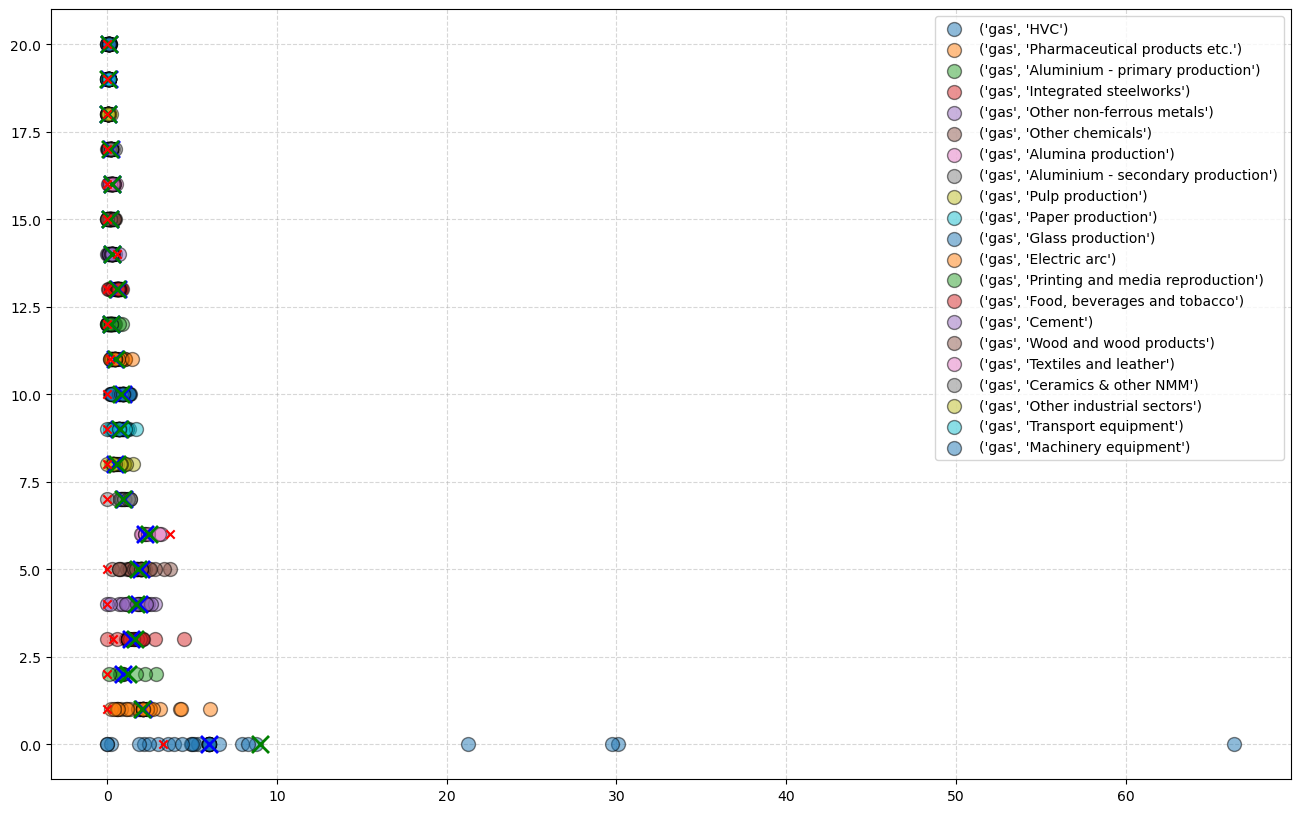

In [169]:
scatter_kwargs = dict(
    s=100,
    alpha=0.5,
    edgecolor='black',
)

fig, ax = plt.subplots(figsize=(16, 10))

i = 0
for _, (pair, values) in enumerate((r := ratios_today.stack()).loc[r.std(axis=1).sort_values(ascending=False).index].iterrows()):
    fuel, product = pair
    if not fuel in 'gas':
        continue

    print(pair)

    values = values.loc[~values.isna()]
    y = np.ones(len(values)) * i
    ax.scatter(values.values, y, label=pair, **scatter_kwargs)
    
    # Plot median as blue cross
    median_value = values.median()
    ax.scatter([median_value], [i], marker='x', color='blue', s=150, linewidths=2)
    
    # Plot mean as green cross
    mean_value = values.mean()
    ax.scatter([mean_value], [i], marker='x', color='green', s=150, linewidths=2)
    
    tomorrow_value = ratios_tomorrow.loc[mapper.get(fuel, fuel), product]
    print('tomorrow value', tomorrow_value)

    ax.scatter([tomorrow_value], [i], marker='x', color='red')

    i += 1

    if i > 20:
        break


ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.show()

In [174]:
ss = ratios_today.rename(mapper).groupby(level=0).sum()
ss

AL                                             \
            Cement Ceramics & other NMM Chlorine Electric arc   
TWh/a                                                           
ammonia   0.000000             0.000000   0.0000     0.000000   
biomass   0.202280             0.091780   0.0000     0.002476   
coke      0.098411             0.057137   0.0000     0.019356   
elec      0.084978             0.096729   3.6000     0.835428   
heat      0.006469             0.006815   0.0000     0.029759   
hydrogen  0.000000             0.000000  -0.9372     0.000000   
methane   0.287645             0.215838   0.0000     0.446083   
naphtha   0.184751             0.093089   0.0000     0.028851   

                                                                  \
         Food, beverages and tobacco Glass production        HVC   
TWh/a                                                              
ammonia                     0.000000         0.000000   0.000000   
biomass                     0.069117         0.005575   0.118108   
coke                        0.055553         0.245440   0.487307   
elec                        0.466061         0.540754   1.492222   
heat                        0.069181         0.000000   1.248865   
hydrogen                    0.000000         0.000000   0.006202   
methane                     0.615628         0.951408   6.031179   
naphtha                     0.069835         0.069021  14.398718   

                                                         ...         XK  \
         Integrated steelworks Methanol Other chemicals  ...        HVC   
TWh/a                                                    ...              
ammonia               0.000000    0.000        0.000000  ...   0.000000   
biomass               0.003593    0.000        0.093036  ...   0.118108   
coke                  0.351180    0.000        0.397414  ...   0.487307   
elec                  0.618070    0.167        1.442725  ...   1.492222   
heat                  0.044435    0.000        0.748438  ...   1.248865   
hydrogen              0.000000    0.000        0.000000  ...   0.006202   
methane               1.235546   10.250        1.974960  ...   6.031179   
naphtha               0.039207    0.000        0.644240  ...  14.398718   

                                                                             \
         Integrated steelworks Machinery equipment Methanol Other chemicals   
TWh/a                                                                         
ammonia               0.000000            0.000000    0.000        0.000000   
biomass               0.003593            0.002887    0.000        0.093036   
coke                  0.351180            0.001374    0.000        0.397414   
elec                  0.618070            0.189899    0.167        1.442725   
heat                  0.044435            0.012131    0.000        0.748438   
hydrogen              0.000000            0.000000    0.000        0.000000   
methane               1.235546            0.114248   10.250        1.974960   
naphtha               0.039207            0.017650    0.000        0.644240   

                                                    \
         Other industrial sectors Paper production   
TWh/a                                                
ammonia                  0.000000         0.000000   
biomass                  0.013576         1.020284   
coke                     0.006001         0.083248   
elec                     0.136883         0.508474   
heat                     0.019658         0.242764   
hydrogen                 0.000000         0.000000   
methane                  0.064405         0.674484   
naphtha                  0.089607         0.052100   

                                                                       \
         Pharmaceutical products etc. Printing and media reproduction   
TWh/a                                                                   
ammonia                      0.000000    

In [ ]:
for ct, group in ss.T.groupby(level=0):
    print(ct)
    print(group)

    break

AL
TWh/a                               ammonia   biomass      coke      elec  \
AL Cement                               0.0  0.202280  0.098411  0.084978   
   Ceramics & other NMM                 0.0  0.091780  0.057137  0.096729   
   Chlorine                             0.0  0.000000  0.000000  3.600000   
   Electric arc                         0.0  0.002476  0.019356  0.835428   
   Food, beverages and tobacco          0.0  0.069117  0.055553  0.466061   
   Glass production                     0.0  0.005575  0.245440  0.540754   
   HVC                                  0.0  0.118108  0.487307  1.492222   
   Integrated steelworks                0.0  0.003593  0.351180  0.618070   
   Methanol                             0.0  0.000000  0.000000  0.167000   
   Other chemicals                      0.0  0.093036  0.397414  1.442725   
   Other industrial sectors             0.0  0.013576  0.006001  0.136883   
   Paper production                     0.0  1.020284  0.083248  0.508474

In [121]:
ratios_today.columns.get_level_values(1).unique()

Index(['Cement', 'Ceramics & other NMM', 'Chlorine', 'Electric arc',
       'Food, beverages and tobacco', 'Glass production', 'HVC',
       'Integrated steelworks', 'Methanol', 'Other chemicals',
       'Other industrial sectors', 'Paper production',
       'Pharmaceutical products etc.', 'Printing and media reproduction',
       'Pulp production', 'Textiles and leather', 'Wood and wood products',
       'Aluminium - secondary production', 'Ammonia', 'Machinery equipment',
       'Other non-ferrous metals', 'Transport equipment', 'Alumina production',
       'Aluminium - primary production'],
      dtype='object')

In [122]:
idx = pd.IndexSlice
ratios_today.loc['gas'].loc[idx[:, 'HVC']]

AL     6.031179
AT     8.794450
BA     6.031179
BE     5.353691
BG     7.956983
CH     6.031179
CZ     2.982643
DE     4.932346
EE     2.193954
ES     6.608887
FI     0.250663
FR     5.137062
GB     6.031179
GR    30.070756
HR     0.000000
HU     8.297624
IT     3.609881
LT     0.000000
LV     2.482943
ME     6.031179
MK     6.031179
NL     5.011942
NO     6.031179
PL    29.726202
PT     1.853864
RO    66.402042
SE     3.956250
SI     4.383730
SK    21.259768
XK     6.031179
Name: gas, dtype: float64

In [49]:
total = ratios.loc['methane'].mul(production.sum().mul(ratios.loc['methane']).sort_values())
total = total.loc[ratios.loc['methane'].index[ratios.loc['methane'] > 0]]

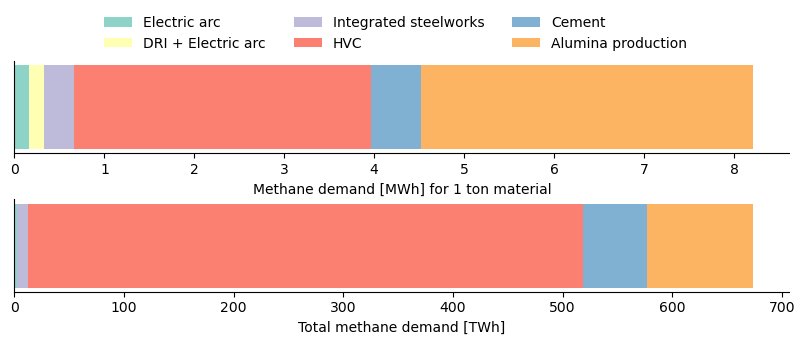

In [ ]:
fig = plt.figure(figsize=(10, 3))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.5)
axs = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

colors = plt.cm.Set3(np.linspace(0, 1, 12))

labels = []
handles = []

left_edge = 0.
color_idx = 0
for name, value in ratios.loc['methane'].items():
    if value == 0.0:
        continue

    labels.append(name)
    handles.append(axs[0].barh(0, value, left=left_edge, color=colors[color_idx % len(colors)]))
    left_edge += value
    color_idx += 1


axs[0].legend(
    handles,
    labels,
    frameon=False,
    ncols=len(labels)//2,
    loc='center left',
    bbox_to_anchor=(0.1, 1.3)
)

axs[0].set_xlabel('Methane demand [MWh] for 1 ton material')
axs[1].set_xlabel('Total methane demand [TWh]')

left_edge = 0.
color_idx = 0
for name, value in total.items():

    axs[1].barh(0, value * 1e-3, left=left_edge, color=colors[color_idx % len(colors)])
    left_edge += value * 1e-3
    color_idx += 1


for ax in axs:
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

In [81]:
import sys
sys.path.append(
    str(Path.cwd().parent / 'scripts')
)
sys.path.append(
    str(Path.cwd().parent)
)
from build_industry_sector_ratios import (
    cc,
    toe_to_MWh,
    eu27,
    sheet_names,
    index,
)
from _helpers import mute_print

In [84]:
def load_idees_data(sector, country="EU27"):
    suffixes = {"out": "", "fec": "_fec", "ued": "_ued", "emi": "_emi"}
    sheets = {k: sheet_names[sector] + v for k, v in suffixes.items()}

    year = 2021

    def usecols(x):
        return isinstance(x, str) or x == year

    with mute_print():
        idees = pd.read_excel(
            Path.cwd().parent / 'data' / 'jrc-idees-2021' / "DE/JRC-IDEES-2021_Industry_DE.xlsx",
            sheet_name=list(sheets.values()),
            index_col=0,
            header=0,
            usecols=usecols,
        )

    for k, v in sheets.items():
        idees[k] = idees.pop(v).squeeze()
        idees[k] = idees[k][year]

    return idees

In [ ]:
def get_chemical_industry_composition():

    sector = "Chemicals Industry"
    idees = load_idees_data(sector)

    names = []
    demands = []






get_chemical_industry_composition()

In [71]:
ratios['Other industrial sectors']

MWh/tMaterial
elec                               0.241559
coal                               0.000000
coke                               0.000000
biomass                            0.070888
methane                            0.000000
hydrogen                           0.000000
heat                               0.007617
naphtha                            0.000000
ammonia                            0.000000
methanol                           0.000000
process emission                   0.000000
process emission from feedstock    0.000000
Name: Other industrial sectors, dtype: float64

In [16]:
production.sum().sort_values()

HVC (chemical recycling)                  0.00
DRI + Electric arc                        0.00
Methanol                               1581.84
Aluminium - primary production         1852.17
Aluminium - secondary production       3086.97
Alumina production                     7086.40
HVC (mechanical recycling)             8225.58
Chlorine                              10102.68
Printing and media reproduction       10656.76
Pharmaceutical products etc.          11445.55
Other non-ferrous metals              13722.58
Ammonia                               16895.58
Other chemicals                       29883.89
Wood and wood products                37159.19
Glass production                      38799.80
Pulp production                       41245.27
HVC                                   46611.60
Electric arc                          75155.96
Textiles and leather                  77278.90
Integrated steelworks                 91857.22
Paper production                      93204.00
Cement       

HVC (mechanical recycling)               0.000000
Textiles and leather                     0.000000
Pulp production                          0.000000
Printing and media reproduction          0.000000
Pharmaceutical products etc.             0.000000
Paper production                         0.000000
Other non-ferrous metals                 0.000000
Other industrial sectors                 0.000000
Other chemicals                          0.000000
Methanol                                 0.000000
Machinery equipment                      0.000000
Transport equipment                      0.000000
Wood and wood products                   0.000000
Glass production                         0.000000
Food, beverages and tobacco              0.000000
DRI + Electric arc                       0.000000
Chlorine                                 0.000000
Ceramics & other NMM                     0.000000
Ammonia                                  0.000000
Aluminium - secondary production         0.000000
